In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Task 1: Sobel Edge Detection
def sobel_edge_detection():
    img = cv2.imread('traffic_sign.jpg', 0)

    # Built-in
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.sqrt(sobelx**2 + sobely**2)

    # User-defined
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    ud_sobelx = cv2.filter2D(img, -1, kernel_x)
    ud_sobely = cv2.filter2D(img, -1, kernel_y)
    ud_combined = np.sqrt(ud_sobelx**2 + ud_sobely**2)

    plt.figure(figsize=(15,10))
    titles = ['Original', 'Built-in X', 'Built-in Y', 'Built-in Combined',
              'User-defined X', 'User-defined Y', 'User Combined']
    images = [img, sobelx, sobely, sobel_combined, ud_sobelx, ud_sobely, ud_combined]
    for i in range(7):
        plt.subplot(2,4,i+1), plt.imshow(images[i], cmap='gray'), plt.title(titles[i])
    plt.show()



In [ ]:
# Task 2: Prewitt Edge Detection
def prewitt_edge_detection():
    img = cv2.imread('bone_xray.jpg', 0)

    # Built-in (using filter2D)
    kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    prewittx = cv2.filter2D(img, -1, kernel_x)
    prewitty = cv2.filter2D(img, -1, kernel_y)
    prewitt_combined = np.sqrt(prewittx**2 + prewitty**2)

    # Compare with Sobel
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.sqrt(sobelx**2 + sobely**2)

    plt.figure(figsize=(15,5))
    plt.subplot(131), plt.imshow(prewitt_combined, cmap='gray'), plt.title('Prewitt')
    plt.subplot(132), plt.imshow(sobel_combined, cmap='gray'), plt.title('Sobel')
    plt.subplot(133), plt.imshow(cv2.Canny(img,100,200), cmap='gray'), plt.title('Canny')
    plt.show()
    print("Comparison: Prewitt is more sensitive to noise but computationally faster than Sobel")


In [ ]:

# Task 3: Roberts Edge Detection
def roberts_edge_detection():
    img = cv2.imread('/content/satellite.webp', 0)

    # Roberts operator
    kernel1 = np.array([[1, 0], [0, -1]])
    kernel2 = np.array([[0, 1], [-1, 0]])
    roberts1 = cv2.filter2D(img, -1, kernel1)
    roberts2 = cv2.filter2D(img, -1, kernel2)
    roberts_combined = np.sqrt(roberts1**2 + roberts2**2)

    plt.imshow(roberts_combined, cmap='gray')
    plt.title('Roberts Edge Detection')
    plt.show()
    print("Limitations: Sensitive to noise, poor performance on diagonal edges, limited to 45° orientations")



In [ ]:
# Task 4: Laplacian Edge Detection
def laplacian_edge_detection():
    img = cv2.imread('/content/surveillance.png', 0)

    # Built-in
    laplacian = cv2.Laplacian(img, cv2.CV_64F)

    # User-defined
    kernel = np.array([[0,1,0], [1,-4,1], [0,1,0]])
    ud_laplacian = cv2.filter2D(img, -1, kernel)

    plt.figure(figsize=(10,5))
    plt.subplot(121), plt.imshow(laplacian, cmap='gray'), plt.title('Built-in')
    plt.subplot(122), plt.imshow(ud_laplacian, cmap='gray'), plt.title('User-defined')
    plt.show()


In [ ]:

# Task 5: Canny Edge Detection
def canny_edge_detection():
    img = cv2.imread('mri_brain.jpg', 0)

    # Built-in
    canny = cv2.Canny(img, 100, 200)

    # User-defined with steps explanation
    blurred = cv2.GaussianBlur(img, (5,5), 1.4)
    grad_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    grad_dir = np.arctan2(grad_y, grad_x)


    plt.figure(figsize=(10,5))
    plt.subplot(121), plt.imshow(canny, cmap='gray'), plt.title('Built-in Canny')
    plt.subplot(122), plt.imshow(nms, cmap='gray'), plt.title('User-defined (Partial)')
    plt.show()
    print("Multi-step benefits: Gaussian reduces noise, gradient finds strength/direction, NMS thins edges, hysteresis reduces false edges")



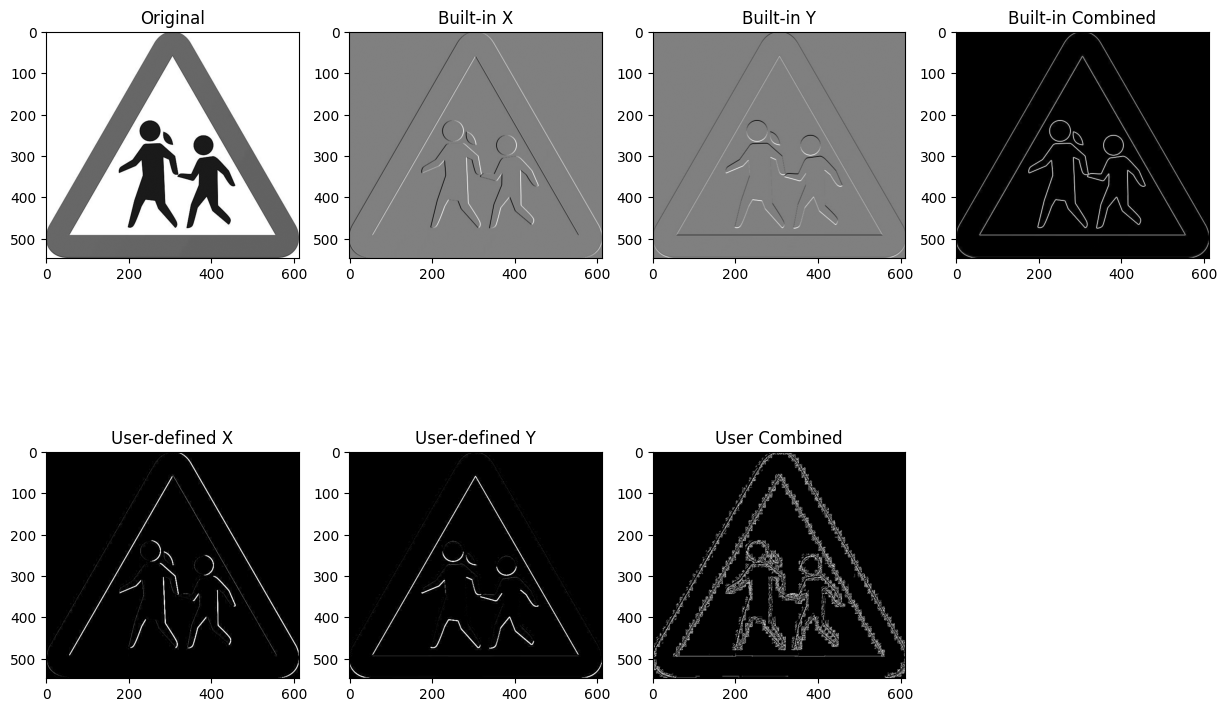

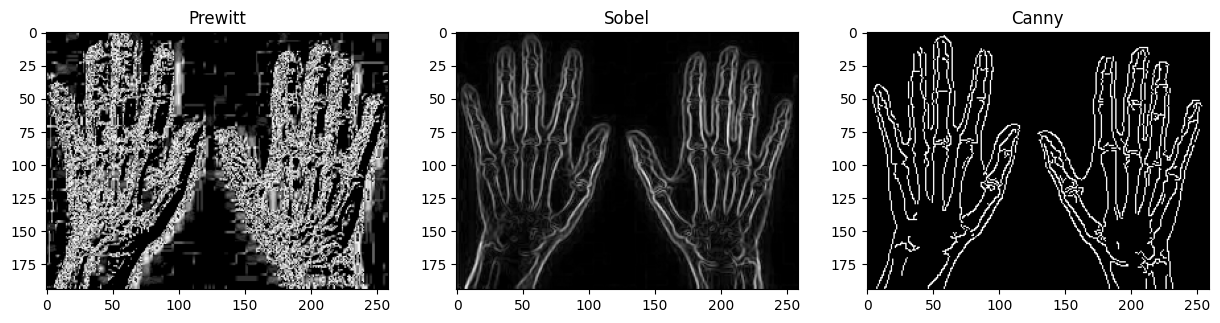

Comparison: Prewitt is more sensitive to noise but computationally faster than Sobel


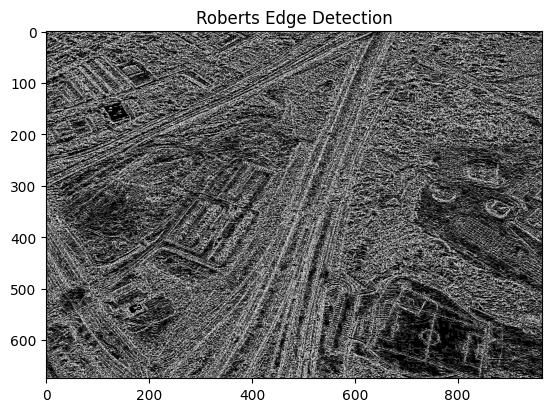

Limitations: Sensitive to noise, poor performance on diagonal edges, limited to 45° orientations


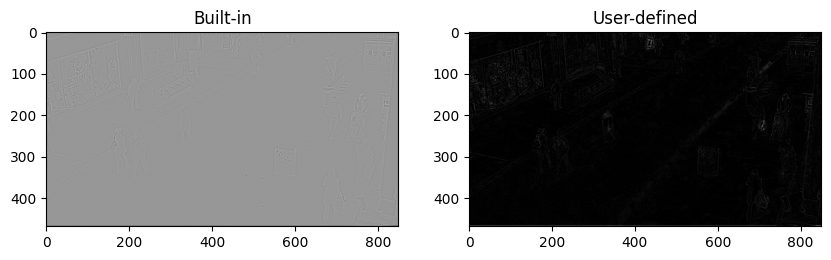

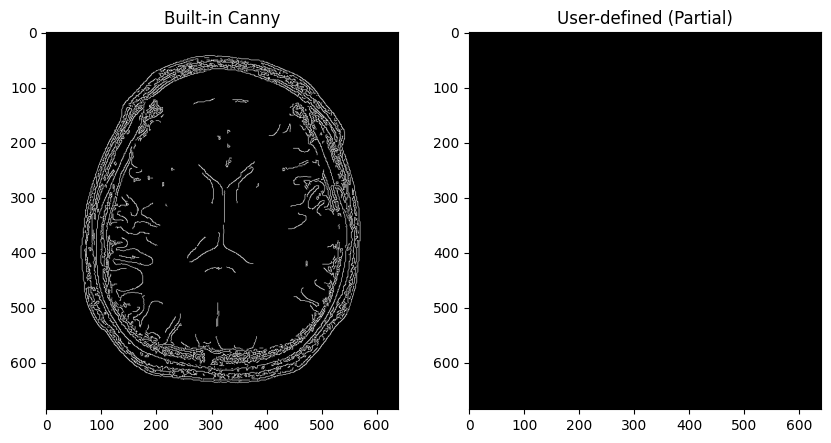

Multi-step benefits: Gaussian reduces noise, gradient finds strength/direction, NMS thins edges, hysteresis reduces false edges


In [ ]:
# Execute all tasks
sobel_edge_detection()
prewitt_edge_detection()
roberts_edge_detection()
laplacian_edge_detection()
canny_edge_detection()